# Privacy-utility tradeoff for Private SpiderBoost

Sweep over privacy budget `epsilon` at fixed `q`, using the `dimma` library. Adapted from `private_spider_boost_criteo/notebooks/privacy_utility_tradeoff.ipynb`.

## 1. Imports

In [1]:
import sys
from pathlib import Path

HERE = Path('.').resolve()
if str(HERE) not in sys.path:
    sys.path.insert(0, str(HERE))

import jax
import jax.numpy as jnp
import numpy as np
from sklearn.metrics import roc_auc_score

import dimma
from dimma import TrainConfig, compute_noise_scales
from dimma.datasets import load_criteo

import model
import visualization as viz

## 2. Data and sweep configuration

In [2]:
FIGS_DIR = HERE / 'figs'
FIGS_DIR.mkdir(exist_ok=True)

data = load_criteo(features='integer', test_fraction=0.2, seed=0, device='cpu')
x_train, y_train = data.x_train, data.y_train
x_test, y_test = data.x_test, data.y_test
n_train, d = x_train.shape

EPSILONS = [0.1, 0.3, 1.0, 3.0, 10.0]
HIDDEN_DIMS = (64, 32)

BASE = dict(
    delta=1.0 / (1.1 * n_train),
    L0=3.0,
    L1=5.0,
    T=200,
    q=30,
    b1=8192,
    b2=512,
    eta=0.01,
    seed=0,
)
BASE

{'delta': 1.1363636363636362e-06,
 'L0': 3.0,
 'L1': 5.0,
 'T': 200,
 'q': 30,
 'b1': 8192,
 'b2': 512,
 'eta': 0.01,
 'seed': 0}

## 3. AUC helper

In [3]:
@jax.jit
def predict_logits(params, x):
    return model.forward(params, x)

def evaluate_auc(params, x, y):
    logits = predict_logits(params, x)
    return float(roc_auc_score(np.asarray(y), np.asarray(logits)))

## 4. Sweep

In [4]:
auc_random_list = []
auc_final_list = []
for eps in EPSILONS:
    cfg = TrainConfig(epsilon=eps, **BASE)
    noise_scales = compute_noise_scales(
        L0=cfg.L0, L1=cfg.L1, epsilon=cfg.epsilon, delta=cfg.delta,
        T=cfg.T, q=cfg.q, n=n_train, b1=cfg.b1, b2=cfg.b2,
    )
    key = jax.random.PRNGKey(cfg.seed)
    init_params = model.init_params(key, input_dim=d, hidden_dims=HIDDEN_DIMS)
    print(f'--- eps = {eps} ---')
    res = dimma.train(
        x_train, y_train,
        per_sample_loss_fn=model.per_sample_bce_loss,
        init_params=init_params,
        config=cfg, noise_scales=noise_scales,
        sampler='poisson',
    )
    a_rand = evaluate_auc(res.params_random, x_test, y_test)
    a_fin = evaluate_auc(res.params_final, x_test, y_test)
    auc_random_list.append(a_rand)
    auc_final_list.append(a_fin)
    print(f'   AUC(w_bar)={a_rand:.4f}   AUC(w_T)={a_fin:.4f}   ({sum(res.history.wall_time_s):.1f}s)')

--- eps = 0.1 ---
   AUC(w_bar)=0.6055   AUC(w_T)=0.6382   (4.0s)
--- eps = 0.3 ---
   AUC(w_bar)=0.6105   AUC(w_T)=0.6403   (3.0s)
--- eps = 1.0 ---
   AUC(w_bar)=0.6121   AUC(w_T)=0.6411   (3.3s)
--- eps = 3.0 ---
   AUC(w_bar)=0.6125   AUC(w_T)=0.6413   (3.0s)
--- eps = 10.0 ---
   AUC(w_bar)=0.6126   AUC(w_T)=0.6414   (2.9s)


## 5. Plot

{'epsilon': [0.1, 0.3, 1.0, 3.0, 10.0], 'auc_random': [0.6055132195112893, 0.6104571345678423, 0.6120758999527841, 0.6124587672947968, 0.6125855258201766], 'auc_final': [0.638248713699495, 0.640332981004902, 0.6411393735808717, 0.6413394712619896, 0.6414021656295094]}


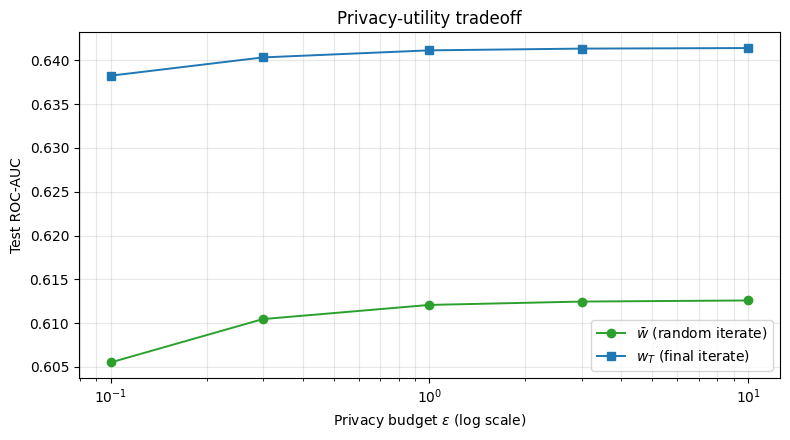

In [5]:
_ = viz.plot_epsilon_sweep(EPSILONS, auc_random_list, auc_final_list,
                            FIGS_DIR / 'privacy_utility_tradeoff.png')
print({'epsilon': EPSILONS, 'auc_random': auc_random_list, 'auc_final': auc_final_list})